# 04b — EnKF Variance Decomposition (3-D MC Dropout)

**Pipeline stage 4b of 9.** Builds the 3-D MC-dropout tensor `mc_preds[t, m, k]` of shape `(n_test_samples, n_enkf, n_mc)` that notebook 08 Section C needs to run the law-of-total-variance decomposition into driver-state and model-weight components.

**What this does.** For each of the `n_enkf` analysis ensemble members produced by notebook 04a (`enkf_diagnostics.npz`), we:

1. Replace the driver columns in the raw chronological dataframe with that member's denoised trajectory.
2. Replay the feature engineering pipeline (`create_features`) per member, since lag/rolling features inherit from the driver state.
3. Apply the **saved** scaler (transform-only — no refit) and build test sequences aligned to notebook 01's saved EnKF test index.
4. Run MC dropout on that member's `X_test` with `N_MC_SAMPLES` samples.

Stacking these gives `mc_preds[t, m, k]`, which decomposes as

`Var_total[t]  =  Var_m [E_k [p(t,m,k)]]   +   E_m [Var_k [p(t,m,k)]]`
`               (driver-state / aleatoric)      (model-weight / epistemic, MC dropout)`

**Inputs**
- `enkf_diagnostics.npz` (from notebook 04a) — ensemble members for the full chronological window.
- `ENKF_LSTM_MODEL_PATH` (from notebook 03 / 02) — the trained LSTM.
- `ENKF_SCALER_FILENAME`, `ENKF_FEATURE_LIST_FILENAME` (from notebook 01).
- Saved raw and EnKF split artifacts from notebook 01; the replay is aligned to the saved EnKF test index.

**Output**
- `MC_PREDS_PATH` — overwritten with a **3-D** float32 tensor of shape `(n_test, n_enkf, n_mc)`. Notebook 08 Section C detects 3-D input and automatically runs the decomposition.

**Cost.** ~`n_enkf × N_MC_SAMPLES` forward passes (e.g. 50 × 50 = 2500), batched. On CPU expect a few minutes; on GPU under a minute.


## Setup

In [1]:
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model

from shared_config import *
print_config_summary()

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DECOMPOSITION_DIR = os.path.join(OUTPUT_DIR, "enkf_decomposition")
os.makedirs(DECOMPOSITION_DIR, exist_ok=True)


def savefig(fig, stem):
    for ext in ("png", "pdf"):
        fp = os.path.join(DECOMPOSITION_DIR, f"{stem}.{ext}")
        fig.savefig(fp, dpi=300, bbox_inches="tight")
        print(f"  saved {fp}")


def display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def save_table(df, fname, title=None):
    fp = os.path.join(DECOMPOSITION_DIR, fname)
    df.to_csv(fp, index=False)
    print(f"  saved {fp}")
    if title:
        print(f"  {title}")
    display_df(df)


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
EnKF Propagator:               SeasonalAR1
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load artifacts

We pull the EnKF members from notebook 04a's saved npz, the fitted scaler and
feature column list from notebook 01, the trained LSTM from notebook 03, and
the saved raw/EnKF split artifacts so replayed member features stay aligned to
notebook 01's test split.

In [2]:
# 1. EnKF ensemble members from notebook 04a
ENKF_DIAGNOSTICS_PATH = os.path.join(INTERMEDIATE_DIR, "enkf_diagnostics.npz")
if not os.path.exists(ENKF_DIAGNOSTICS_PATH):
    raise FileNotFoundError(
        f"Missing {ENKF_DIAGNOSTICS_PATH}. Run notebook 04a first.")

enkf_diag = np.load(ENKF_DIAGNOSTICS_PATH, allow_pickle=True)
members = enkf_diag["members"]                     # (n_enkf, T, n_drivers)
state_vars = list(enkf_diag["state_vars"])
propagator_name = str(enkf_diag["propagator"].item()) if "propagator" in enkf_diag.files else "unknown"
n_train = int(enkf_diag["n_train"])
n_val = int(enkf_diag["n_val"])
n_test = int(enkf_diag["n_test"])
n_enkf, T, n_drivers = members.shape
print(f"Loaded EnKF members shape: {members.shape}")
print(f"Diagnostics propagator: {propagator_name}")
print(f"State variables: {state_vars}")
print(f"Splits: train={n_train}, val={n_val}, test={n_test}")

# 2. Saved scaler + feature column list (EnKF branch)
enkf_scaler = joblib.load(ENKF_SCALER_FILENAME)
enkf_feature_columns = joblib.load(ENKF_FEATURE_LIST_FILENAME)
print(f"\nScaler: {type(enkf_scaler).__name__}")
print(f"Feature columns ({len(enkf_feature_columns)}): {enkf_feature_columns[:6]}...")

# 3. Trained LSTM
if not os.path.exists(ENKF_LSTM_MODEL_PATH):
    raise FileNotFoundError(
        f"Missing {ENKF_LSTM_MODEL_PATH}. Run notebook 03 (training) first.")
model = load_model(ENKF_LSTM_MODEL_PATH, compile=False)
print(f"\nLoaded model from {ENKF_LSTM_MODEL_PATH}")

MODEL_SEQ_LENGTH = int(model.input_shape[1])
MODEL_N_CHANNELS = int(model.input_shape[-1])
SEQUENCE_LENGTH = MODEL_SEQ_LENGTH   # override the config import for this notebook
print(f"\nModel expects sequences: seq_length={MODEL_SEQ_LENGTH}, channels={MODEL_N_CHANNELS}")
if MODEL_SEQ_LENGTH != globals().get("SEQUENCE_LENGTH_CONFIG", SEQUENCE_LENGTH):
    pass

# 4. Raw chronological full-window dataframe (pre-feature-engineering).
# Reuses the raw splits saved by notebook 01 since they share an index with
# the EnKF members from notebook 04a.
train_df = pd.read_parquet(TRAIN_DF_PATH)
val_df = pd.read_parquet(VAL_DF_PATH)
test_df = pd.read_parquet(TEST_DF_PATH)
full_df = pd.concat([train_df, val_df, test_df], axis=0).sort_index()
assert len(full_df) == T, f"Length mismatch: full_df={len(full_df)} vs members.T={T}"
print(f"\nFull chronological frame: {full_df.shape}, index {full_df.index.min().date()} -> {full_df.index.max().date()}")


# 5. Load saved EnKF-preprocessed full df so we can copy over the _enkf_std
# columns that nb01's enkf_preprocess_drivers wrote with append_std=True.
# These columns encode the per-step ensemble standard deviation of each state
# variable; the LSTM and scaler were trained on them, so the per-member replay
# below has to re-emit them. They describe the assimilation step (not any
# individual member), so they're identical across the 50 replays in this
# notebook.
enkf_train_orig = pd.read_parquet(ENKF_TRAIN_DF_PATH)
enkf_val_orig = pd.read_parquet(ENKF_VAL_DF_PATH)
enkf_test_orig = pd.read_parquet(ENKF_TEST_DF_PATH)
enkf_full_orig = pd.concat([enkf_train_orig, enkf_val_orig, enkf_test_orig], axis=0).sort_index()
enkf_std_cols = [c for c in enkf_full_orig.columns if c.endswith("_enkf_std")]
print(f"\nLoaded saved EnKF-preprocessed full df: {enkf_full_orig.shape}")
print(f"_enkf_std columns to propagate per member ({len(enkf_std_cols)}): {enkf_std_cols}")


Loaded EnKF members shape: (50, 1605, 6)
Diagnostics propagator: SeasonalAR1
State variables: [np.str_('peace_discharge'), np.str_('peace_TN'), np.str_('peace_TP'), np.str_('kb'), np.str_('wind_u'), np.str_('wind_v')]
Splits: train=1123, val=240, test=242

Scaler: RobustScaler
Feature columns (58): ['kb', 'zos', 'salinity', 'water_temp', 'peace_discharge', 'peace_TN']...

Loaded model from output_refactored/best_lstm_model_lstm_enkf_preprocessor_tuned_weighted.keras

Model expects sequences: seq_length=26, channels=58

Full chronological frame: (1605, 53), index 1993-03-29 -> 2023-12-25

Loaded saved EnKF-preprocessed full df: (1605, 59)
_enkf_std columns to propagate per member (6): ['peace_discharge_enkf_std', 'peace_TN_enkf_std', 'peace_TP_enkf_std', 'kb_enkf_std', 'wind_u_enkf_std', 'wind_v_enkf_std']


## Inline pipeline functions

The feature-engineering function from notebook 01 is defined inline here so
this notebook is self-contained. The sequence builder is imported from
`lstm_utils` so it stays identical to what notebooks 01–06 use.

If your project version of `create_features` ever changes, replace this
definition with `from <your_module> import create_features` and remove the
inline copy.

In [3]:
from lstm_utils import create_sequences_from_df
import onset_utils as ou


def create_features(df, target_col, target_binary_col, base_features,
                    use_enhanced=False, basic_cfg=None, enhanced_cfg=None,
                    verbose=False):
    """Copy of notebook 01 Part 3 with verbose printing made optional."""
    if df is None:
        return None

    df_featured = df.copy()
    if use_enhanced:
        cfg = enhanced_cfg if enhanced_cfg else ENHANCED_LAG_CONFIG
        env_lags = cfg.get("env_lags", [1])
        kb_lags = cfg.get("kb_lags", [])
        kb_rolling_windows = cfg.get("kb_rolling_windows", [])
        discharge_rolling_window = cfg.get("discharge_rolling_window", None)
    else:
        cfg = basic_cfg if basic_cfg else BASIC_LAG_CONFIG
        env_lags = cfg.get("env_lags", [])
        kb_lags = cfg.get("kb_lags", [])
        kb_rolling_windows = []
        discharge_rolling_window = None

    max_lag_needed = 0

    # KB weekly lags
    if target_col in df.columns and kb_lags:
        df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
        for lag in kb_lags:
            df_featured[f"{target_col}_L{lag}"] = df[target_col].shift(lag)
            max_lag_needed = max(max_lag_needed, lag)

    # KB rolling windows
    if use_enhanced and kb_rolling_windows and target_col in df.columns and target_binary_col in df.columns:
        target_binary = df[target_binary_col]
        max_roll_lag = 0
        for i, (start_lag, end_lag) in enumerate(kb_rolling_windows):
            window_size = end_lag - start_lag + 1
            month_id = f"M{i+1}"
            max_roll_lag = max(max_roll_lag, end_lag)
            df_featured[f"{target_col}_{month_id}_mean"] = (
                df[target_col].rolling(window=window_size, min_periods=1).mean().shift(start_lag))
            df_featured[f"{target_binary_col}_{month_id}_prop"] = (
                target_binary.rolling(window=window_size, min_periods=1).mean().shift(start_lag))
        max_lag_needed = max(max_lag_needed, max_roll_lag)

    # Discharge rolling average
    discharge_col = "peace_discharge"
    if use_enhanced and discharge_rolling_window and discharge_col in df.columns:
        window_size = discharge_rolling_window
        start_lag = 1
        col_name = f"{discharge_col}_{window_size}w_avg_L{start_lag}"
        df_featured[col_name] = (
            df[discharge_col].rolling(window=window_size, min_periods=1).mean().shift(start_lag))
        max_lag_needed = max(max_lag_needed, window_size + start_lag - 1)

    # Environmental lags
    if env_lags:
        for feature in base_features:
            if feature in df.columns:
                df[feature] = pd.to_numeric(df[feature], errors="coerce")
                for lag in env_lags:
                    df_featured[f"{feature}_L{lag}"] = df[feature].shift(lag)
                    max_lag_needed = max(max_lag_needed, lag)

    if max_lag_needed > 0:
        df_processed = df_featured.iloc[max_lag_needed:].copy()
    else:
        df_processed = df_featured.copy()

    # Drop any all-NaN columns and duplicate columns
    all_nan_cols = df_processed.columns[df_processed.isnull().all()].tolist()
    if all_nan_cols:
        df_processed = df_processed.dropna(axis=1, how="all")
    df_processed = df_processed.loc[:, ~df_processed.columns.duplicated()]

    return df_processed


def split_data_chronological(df, train_ratio, val_ratio):
    """Same logic as notebook 01 Part 4 but silent."""
    n_total = len(df)
    n_tr = int(n_total * train_ratio)
    n_va = int(n_total * val_ratio)
    return df.iloc[:n_tr].copy(), df.iloc[n_tr:n_tr + n_va].copy(), df.iloc[n_tr + n_va:].copy()


def transform_with_saved_scaler(df, scaler, feature_columns, target_binary_col):
    """Apply the previously-fitted scaler to a member dataframe.

    Only feature_columns are scaled; the target column is appended unchanged so
    create_sequences_from_df can extract y.
    """
    available = [c for c in feature_columns if c in df.columns]
    missing = [c for c in feature_columns if c not in df.columns]
    if missing:
        raise KeyError(f"Member dataframe missing expected feature columns: {missing}")
    scaled_values = scaler.transform(df[available])
    scaled_df = pd.DataFrame(scaled_values, index=df.index, columns=available)
    if target_binary_col in df.columns:
        scaled_df[target_binary_col] = df[target_binary_col].values
    return scaled_df


def recompute_onset_feature_columns(df):
    """Refresh onset-derived columns after replacing member driver states."""
    out = df.copy()
    if {"wind_u", "wind_v"}.issubset(out.columns):
        out["wind_alongshore"] = ou.alongshore_wind(
            out["wind_u"], out["wind_v"], shelf_angle_deg=340.0)
    out = ou.add_rate_of_change_features(
        out,
        cols=["water_temp", "peace_TN", "peace_TP", "peace_discharge", "zos"],
        windows=(2, 4, 8),
        suffix="d",
    )
    out = ou.add_cumulative_anomaly_features(
        out,
        cols=["water_temp", "peace_TN", "peace_TP"],
        climatology_period=52,
        accumulation_windows=(4, 8, 12),
    )
    if TARGET_BINARY_COL in out.columns:
        wsb = pd.Series(ou.weeks_since_last_bloom(out[TARGET_BINARY_COL]), index=out.index)
        out["weeks_since_bloom"] = wsb.fillna(wsb.max() if wsb.notna().any() else 0)
    return out

print("Inline pipeline functions defined.")


Inline pipeline functions defined.


## Per-member pipeline replay

For each EnKF ensemble member, we substitute its denoised driver trajectory into
the full chronological frame, re-run feature engineering and scaling, build the
test sequences using the same `SEQUENCE_LENGTH` and `FORECAST_HORIZON` used
throughout the pipeline, and run MC dropout on the resulting `X_test`.

The MC-dropout function below is the same one used in notebook 04 Cell 8.

In [4]:
from lstm_utils import create_sequences_from_df


def mc_dropout_predict(model, X, n_samples, batch_size=512):
    X = np.asarray(X, dtype=np.float32)
    preds = []
    for start in range(0, len(X), batch_size):
        xb = tf.convert_to_tensor(X[start:start + batch_size], dtype=tf.float32)
        batch_preds = [model(xb, training=True).numpy().reshape(-1) for _ in range(n_samples)]
        preds.append(np.stack(batch_preds, axis=1))
    return np.vstack(preds).astype(np.float32)


def build_test_X_for_member(member_idx):
    """Replay create_features + scaling + sequence creation for one ensemble member.

    Sequence layout: lstm_utils.create_sequences_from_df uses the target column
    (target_col_idx) ONLY to build y and drops it from the X channels. We order
    columns as [enkf_feature_columns..., TARGET_BINARY_COL] and point
    target_col_idx at that last column, so X ends up containing the feature
    columns only — matching the channels the saved model was trained on.
    """
    df_m = full_df.copy()
    df_m.loc[:, state_vars] = members[member_idx]
    for col in enkf_std_cols:
        df_m[col] = enkf_full_orig[col].reindex(df_m.index).values
    df_m = recompute_onset_feature_columns(df_m)
    df_processed = create_features(
        df_m,
        TARGET_COL,
        TARGET_BINARY_COL,
        BASE_FEATURES,
        use_enhanced=USE_ENHANCED_FEATURES,
        basic_cfg=BASIC_LAG_CONFIG,
        enhanced_cfg=ENHANCED_LAG_CONFIG,
    )
    # Align to the saved EnKF test split index from notebook 01. Recomputing
    # train/val/test boundaries after create_features() drops leading lag rows
    # a second time and shortens the replay by two samples.
    missing_idx = enkf_test_orig.index.difference(df_processed.index)
    if len(missing_idx) > 0:
        raise ValueError(
            f"Member replay lost {len(missing_idx)} saved EnKF test timestamps; "
            f"first missing={missing_idx[0]}"
        )
    test_df_m = df_processed.loc[enkf_test_orig.index].copy()
    test_scaled_m = transform_with_saved_scaler(test_df_m, enkf_scaler, enkf_feature_columns, TARGET_BINARY_COL)

    # Reorder to [features..., target] so target_col_idx is known.
    ordered_cols = list(enkf_feature_columns) + [TARGET_BINARY_COL]
    test_scaled_ordered = test_scaled_m[ordered_cols]
    target_col_idx = len(enkf_feature_columns)

    X_test_m, _ = create_sequences_from_df(
        test_scaled_ordered,
        seq_length=SEQUENCE_LENGTH,
        target_col_idx=target_col_idx,
        pred_step=FORECAST_HORIZON,
        return_targets=True,
    )
    return X_test_m


# Probe shape
print("Probing member 0 to determine X_test shape...")
X_probe = build_test_X_for_member(0)
n_samples = len(X_probe)
print(f"  X_test shape per member: {X_probe.shape}  (channels = features only; target dropped from X)")
expected_n_samples = len(enkf_test_orig) - SEQUENCE_LENGTH - FORECAST_HORIZON + 1
assert n_samples == expected_n_samples, (
    f"Replay sample count {n_samples} does not match saved EnKF test split "
    f"length {len(enkf_test_orig)} with seq_length={SEQUENCE_LENGTH}, "
    f"horizon={FORECAST_HORIZON} -> {expected_n_samples}."
)

# Sanity-check against the model
expected_channels = model.input_shape[-1]
got_channels = X_probe.shape[-1]
assert got_channels == expected_channels, (
    f"Channel mismatch: model expects {expected_channels}, got {got_channels}. "
    f"len(enkf_feature_columns)={len(enkf_feature_columns)} (target is dropped from X). "
    "Verify enkf_feature_columns matches what the saved model was trained on."
)
print(f"  Pre-allocating mc_preds_3d: ({n_samples}, {n_enkf}, {N_MC_SAMPLES})")

mc_preds_3d = np.zeros((n_samples, n_enkf, N_MC_SAMPLES), dtype=np.float32)
mc_preds_3d[:, 0, :] = mc_dropout_predict(model, X_probe, n_samples=N_MC_SAMPLES)
print(f"  Member  0/{n_enkf} done.")

t_start = time.time()
for m in range(1, n_enkf):
    X_m = build_test_X_for_member(m)
    mc_preds_3d[:, m, :] = mc_dropout_predict(model, X_m, n_samples=N_MC_SAMPLES)
    if (m + 1) % 10 == 0 or m == n_enkf - 1:
        elapsed = time.time() - t_start
        rate = (m + 1) / elapsed
        eta = (n_enkf - m - 1) / rate
        print(f"  Member {m+1:2d}/{n_enkf} done. Elapsed {elapsed:.1f}s, ETA {eta:.1f}s")

print(f"\nDone. mc_preds_3d shape: {mc_preds_3d.shape}, dtype: {mc_preds_3d.dtype}")

Probing member 0 to determine X_test shape...
  X_test shape per member: (216, 26, 58)  (channels = features only; target dropped from X)
  Pre-allocating mc_preds_3d: (216, 50, 50)
  Member  0/50 done.
  Member 10/50 done. Elapsed 29.8s, ETA 119.3s
  Member 20/50 done. Elapsed 62.8s, ETA 94.3s
  Member 30/50 done. Elapsed 95.9s, ETA 64.0s
  Member 40/50 done. Elapsed 128.8s, ETA 32.2s
  Member 50/50 done. Elapsed 161.8s, ETA 0.0s

Done. mc_preds_3d shape: (216, 50, 50), dtype: float32


## Variance decomposition summary

The law-of-total-variance decomposition implemented in notebook 08 Section C
splits per-sample predictive variance into

- `var_driver = Var_m [E_k [p(t,m,k)]]` — variance across EnKF members of each member's MC-mean. This is the **driver-state (aleatoric)** component contributed by the EnKF.
- `var_model = E_m [Var_k [p(t,m,k)]]` — average MC-dropout variance within each member. This is the **model-weight (epistemic)** component.

We report the same decomposition here as a sanity check before writing out the tensor.

  saved output_refactored/intermediate\enkf_var_decomposition.npz  (n=216)
  saved output_refactored/enkf_decomposition\Table4e_variance_decomposition_summary.csv
  Variance decomposition headline summary


,metric,value
0,mean var_driver (EnKF / aleatoric),0.008642
1,mean var_model (MC dropout / epistemic),0.001614
2,mean total predictive variance,0.010255
3,mean driver_fraction,0.700676
4,median driver_fraction,0.832494
5,fraction of samples where driver > model,0.777778


  saved output_refactored/enkf_decomposition\Table4e_variance_decomposition_per_sample.csv
  saved output_refactored/enkf_decomposition\Fig4e_variance_decomposition.png
  saved output_refactored/enkf_decomposition\Fig4e_variance_decomposition.pdf


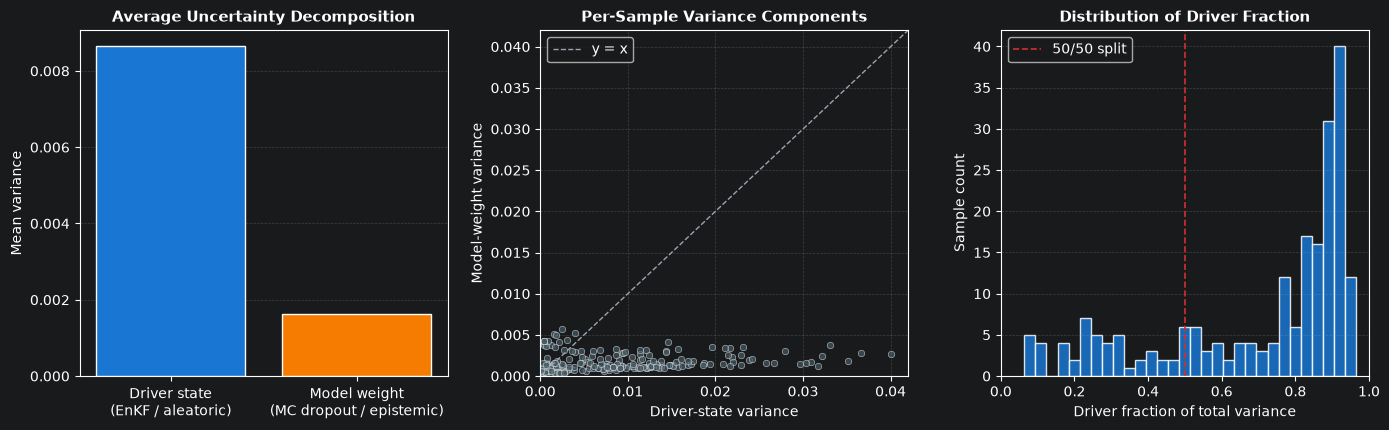

In [5]:
per_member_mean = mc_preds_3d.mean(axis=2)   # (n_samples, n_enkf)
per_member_var  = mc_preds_3d.var(axis=2)    # (n_samples, n_enkf)
var_driver = per_member_mean.var(axis=1)     # (n_samples,)
var_model  = per_member_var.mean(axis=1)     # (n_samples,)
total_var  = var_driver + var_model
driver_fraction = var_driver / np.maximum(total_var, 1e-12)

# Persist the per-forecast decomposition so nb04's total-variance CI loader
# (and any other consumer) can read it. nb04 looks for this exact file/keys.
VAR_DECOMP_NPZ = os.path.join(INTERMEDIATE_DIR, "enkf_var_decomposition.npz")
np.savez(VAR_DECOMP_NPZ,
         var_driver=np.asarray(var_driver, dtype=np.float64),
         var_model=np.asarray(var_model, dtype=np.float64),
         total_variance=np.asarray(total_var, dtype=np.float64))
print(f"  saved {VAR_DECOMP_NPZ}  (n={len(var_driver)})")

summary = pd.DataFrame({
    "metric": [
        "mean var_driver (EnKF / aleatoric)",
        "mean var_model (MC dropout / epistemic)",
        "mean total predictive variance",
        "mean driver_fraction",
        "median driver_fraction",
        "fraction of samples where driver > model",
    ],
    "value": [
        float(var_driver.mean()),
        float(var_model.mean()),
        float(total_var.mean()),
        float(driver_fraction.mean()),
        float(np.median(driver_fraction)),
        float((var_driver > var_model).mean()),
    ],
})
save_table(summary, "Table4e_variance_decomposition_summary.csv",
           "Variance decomposition headline summary")

# Per-sample table (for downstream analysis)
per_sample = pd.DataFrame({
    "var_driver": var_driver,
    "var_model": var_model,
    "total_variance": total_var,
    "driver_fraction": driver_fraction,
})
per_sample.to_csv(os.path.join(DECOMPOSITION_DIR, "Table4e_variance_decomposition_per_sample.csv"), index=False)
print(f"  saved {os.path.join(DECOMPOSITION_DIR, 'Table4e_variance_decomposition_per_sample.csv')}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

axes[0].bar(["Driver state\n(EnKF / aleatoric)", "Model weight\n(MC dropout / epistemic)"],
            [var_driver.mean(), var_model.mean()],
            color=["#1976D2", "#F57C00"], edgecolor="white", zorder=3)
axes[0].set_ylabel("Mean variance")
axes[0].set_title("Average Uncertainty Decomposition", fontweight="bold", fontsize=11)
axes[0].grid(axis="y", alpha=0.25, linestyle="--", zorder=0)

axes[1].scatter(var_driver, var_model, s=22, alpha=0.7,
                color="#455A64", edgecolor="white", linewidth=0.4)
lim = max(var_driver.max(), var_model.max()) * 1.05
axes[1].plot([0, lim], [0, lim], "--", color="#9CA3AF", lw=1, label="y = x")
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("Driver-state variance")
axes[1].set_ylabel("Model-weight variance")
axes[1].set_title("Per-Sample Variance Components", fontweight="bold", fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.25, linestyle="--")

axes[2].hist(driver_fraction, bins=30, color="#1976D2", edgecolor="white", alpha=0.85)
axes[2].axvline(0.5, color="#D32F2F", linestyle="--", lw=1.2, label="50/50 split")
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Driver fraction of total variance")
axes[2].set_ylabel("Sample count")
axes[2].set_title("Distribution of Driver Fraction", fontweight="bold", fontsize=11)
axes[2].legend(frameon=True)
axes[2].grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
savefig(fig, "Fig4e_variance_decomposition")
plt.show()


## Persist the 3-D tensor

Overwrites `MC_PREDS_PATH` with the 3-D tensor. Notebook 08 Section C will
automatically detect `mc_preds.ndim == 3` and run the proper driver-vs-model
decomposition (its 2-D fallback path no longer activates).

We also save the 2-D MC mean alongside `lstm_enkf_p_test` for downstream
notebooks that still expect a 1-D probability stream.

In [6]:
# Sanity check: shape and dtype
assert mc_preds_3d.ndim == 3, f"Expected 3-D tensor, got {mc_preds_3d.ndim}-D"
print(f"Final tensor shape: {mc_preds_3d.shape}  (n_samples, n_enkf, n_mc)")

# Overwrite MC_PREDS_PATH with the 3-D tensor.
np.save(MC_PREDS_PATH, mc_preds_3d)
print(f"\nWrote {MC_PREDS_PATH}  shape={mc_preds_3d.shape}")

# Also overwrite the 1-D mean-probability stream so nb09 etc. see the same
# point estimate but now derived from the full ensemble.
enkf_hybrid_prob_3d = mc_preds_3d.mean(axis=(1, 2)).astype(np.float32)
np.save(LSTM_ENKF_TEST_PROBS_PATH, enkf_hybrid_prob_3d)
print(f"Wrote {LSTM_ENKF_TEST_PROBS_PATH}  shape={enkf_hybrid_prob_3d.shape}")

print("\nNext step: re-run notebook 08 Section C. With mc_preds now 3-D, the")
print("decomposition path activates and produces Table 8C / Fig 8C populated")
print("with var_driver and var_model columns.")


# --- Patch the shipped per-forecast CSV with TOTAL-variance uncertainty -------
# nb04 wrote predictions_enkf_mc.csv with MC-dropout-only intervals (the driver
# term -- ~2/3 of total variance -- was unavailable at that stage). Now that the
# full driver x member ensemble exists, rebuild per-forecast uncertainty from it:
# total-variance std, an EMPIRICAL 95% CI over all draws (probabilities are
# bounded, so quantiles beat a normal approximation), and the BALD
# mutual-information signal. This is the single-pass fix for audit #4 and feeds
# the calibration check in nb08 (audit #8).
PRED_CSV = (ENKF_MC_PREDICTIONS_CSV_PATH if "ENKF_MC_PREDICTIONS_CSV_PATH" in dir()
            else os.path.join(OUTPUT_DIR, "predictions_enkf_mc.csv"))

if os.path.exists(PRED_CSV):
    pred_df = pd.read_csv(PRED_CSV, index_col=0)
    n_csv, n_ens = len(pred_df), mc_preds_3d.shape[0]
    if n_ens != n_csv:
        n = min(n_ens, n_csv)
        print(f"[warn] CSV rows ({n_csv}) != ensemble samples ({n_ens}); "
              f"patching trailing {n} (sequence trimming is front-aligned).")
        tens = mc_preds_3d[-n:]
        pred_df = pred_df.iloc[-n:].copy()
    else:
        tens = mc_preds_3d

    flat = tens.reshape(tens.shape[0], -1)              # (n, n_enkf*n_mc)
    p_mean = flat.mean(axis=1)
    vd = tens.mean(axis=2).var(axis=1)                  # driver variance
    vm = tens.var(axis=2).mean(axis=1)                  # model variance
    y_std_total = np.sqrt(vd + vm)

    _eps = 1e-12
    def _H(p):
        p = np.clip(p, _eps, 1 - _eps)
        return -(p * np.log(p) + (1 - p) * np.log(1 - p))
    total_entropy      = _H(p_mean)
    expected_entropy   = _H(flat).mean(axis=1)
    mutual_information = total_entropy - expected_entropy

    pred_df["y_mean"]             = p_mean
    pred_df["y_std"]              = y_std_total
    pred_df["y_std_model"]        = np.sqrt(vm)
    pred_df["ci_lower"]           = np.quantile(flat, 0.025, axis=1)
    pred_df["ci_upper"]           = np.quantile(flat, 0.975, axis=1)
    pred_df["entropy"]            = total_entropy        # H(mean); back-compat
    pred_df["expected_entropy"]   = expected_entropy
    pred_df["mutual_information"] = mutual_information    # genuine ensemble signal

    pred_df.to_csv(PRED_CSV)
    print(f"Patched {PRED_CSV}: total-variance CI (mean width "
          f"{np.mean(pred_df['ci_upper'] - pred_df['ci_lower']):.3f}) + BALD MI.")
else:
    print(f"[notice] {PRED_CSV} not found; skipped CSV patch (run nb04 first).")


Final tensor shape: (216, 50, 50)  (n_samples, n_enkf, n_mc)

Wrote output_refactored/intermediate\mc_predictions.npy  shape=(216, 50, 50)
Wrote output_refactored/intermediate\lstm_enkf_test_probs.npy  shape=(216,)

Next step: re-run notebook 08 Section C. With mc_preds now 3-D, the
decomposition path activates and produces Table 8C / Fig 8C populated
with var_driver and var_model columns.
Patched output_refactored/predictions_enkf_mc.csv: total-variance CI (mean width 0.349) + BALD MI.
